# Part 2 (35 points) Image Classification using SVM


In this problem, we will use Support Vector Machines (SVMs) to build a binary image classifier. We will be solving the SVM optimization problem using a general purpose convex optimization package CVXOPT as well as using a scikit-learn library function based on a customized solver known as LIBSVM.


The dataset consists of 6, 862 images across 11 different weather classes. The dataset has been taken from kaggle ( kaggle link). For the purpose of this assignment, we have split the data into test and train, which can be accessed from the link: Assignment2 starter code. Each class has its own folder containing images of varying resolutions.

Before training the SVM, some pre-processing steps must be applied. Each image must then be resized to 100×100 pixels, followed by center cropping to ensure uniformity. Since SVMs require numerical feature vectors, each RGB image of size 100 × 100 × 3 should be flattened into a onedimensional vector of length 30, 000. As is the general practice for images, perform a min max scaling for normalization (scale range [0, 255] into [0, 1] by dividing by 255). 

Once pre-processing is complete, the SVM classifier will be trained using both approaches, and
their performance will be compared to evaluate the effectiveness of each method.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
from PIL import Image

import nltk
import re
import string as s

from nltk.corpus import stopwords
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, accuracy_score
from sklearn.naive_bayes import MultinomialNB 


from nltk.corpus import stopwords
from wordcloud import WordCloud

from sklearn.feature_extraction.text  import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics  import f1_score,accuracy_score
from sklearn.metrics import  confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier

import time
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from nltk.stem import PorterStemmer
import string


In [16]:
%load_ext autoreload
%autoreload 2
from svm import SupportVectorMachine

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from PIL import Image
import numpy as np


def preprocess_image(image_path):
    # Open the image file
    img = Image.open(image_path).convert('RGB')
    #make sure the image is of the right shape
    
    # Resize the image to 100x100 pixels
    img = img.resize((100, 100))
    
    assert img.size == (100,100)
    # Convert the image to a numpy array, make sure its size is 100x100x3
    img_array = np.array(img)
    
    # Flatten the image to a 1D array of length 30,000
    img_flattened = img_array.flatten()
    
    # Normalize the pixel values to the range [0, 1]
    img_normalized = img_flattened / 255.0
    
    #make sure the image is of the right shape
    assert img_normalized.shape == (30000,)

    return img_normalized





In [8]:
train_img = dict()



for folder in os.listdir('../data/Q2/train'):
    print(folder)
    df = pd.DataFrame(columns=[ 'image_id', 'feature_vector'])
    if os.path.isdir(os.path.join('../data/Q2/train', folder)):
        for file in os.listdir(os.path.join('../data/Q2/train', folder)):
   
            if file.endswith('.jpg'):
                image_path = os.path.join('../data/Q2/train', folder, file)
                image_id = file.replace('.jpg', '')
                feature_vector = preprocess_image(image_path)
                df = pd.concat([ df,pd.DataFrame([{'image_id': image_id, 'label': folder, 'feature_vector': feature_vector}])], ignore_index=True )
    train_img[folder] = df



lightning
sandstorm
glaze
rain
rime
frost
fogsmog
hail
dew
rainbow
snow


In [9]:
test_img = dict()



for folder in os.listdir('../data/Q2/test'):
    print(folder)
    df = pd.DataFrame(columns=[ 'image_id', 'feature_vector'])
    if os.path.isdir(os.path.join('../data/Q2/test', folder)):
        for file in os.listdir(os.path.join('../data/Q2/test', folder)):
   
            if file.endswith('.jpg'):
                image_path = os.path.join('../data/Q2/test', folder, file)
                image_id = file.replace('.jpg', '')
                feature_vector = preprocess_image(image_path)
                df = pd.concat([ df,pd.DataFrame([{'image_id': image_id, 'feature_vector': feature_vector}])], ignore_index=True )

    test_img[folder] = df



lightning
sandstorm
glaze
rain
rime
frost
fogsmog
hail
dew
rainbow
snow


# A (18 points) Binary Classification:

Let d be the last 2 digits of your entry number. Take the subset of images for the classes d and (d + 1) mod 11) from the train/validation data provided to you (arranged alphabetically, i.e., dew is 0) and perform the following experiments in the context of binary classification.

In [13]:
fog_smog_train = train_img['fogsmog']
frost_train = train_img['frost']



fog_smog_train['label'] = 1
frost_train['label'] = 0

combined_train = pd.concat([fog_smog_train, frost_train], ignore_index=True)

combined_train = combined_train.sample(frac=1).reset_index(drop=True)

fog_smog_test = test_img['fogsmog']
frost_test = test_img['frost']

fog_smog_test['label'] = 1
frost_test['label'] = 0

combined_test = pd.concat([fog_smog_test, frost_test], ignore_index=True)
combined_test = combined_test.sample(frac=1).reset_index(drop=True)


# 1 (8 points) 
Download and install the CVXOPT package. Formulate the SVM dual optimization problem with a linear kernel in a form that can be solved using the CVXOPT package. The objective function should be expressed in the standard quadratic programming form αTPα + qTα + c matrix where P is an m × m matrix ( m being the number of training examples), q is an m-sized column vector and c is a constant. For your optimization problem, remember to use the constraints on αi ’s in the dual. Use the SVM formulation which can handle noise and use C = 1.0 (i.e. C in the expression 1/2wTw + C ∗Pi ξi ). You can refer this link to get a working overview of cvxopt module and it’s formulation.

In [12]:
X_train, y_train = combined_train["feature_vector"], combined_train["label"]
X_test, y_test = combined_test["feature_vector"], combined_test["label"]

# Import SVM implementation

X_train = np.array(X_train.tolist())
X_test = np.array(X_test.tolist())
y_train = np.array(y_train)
y_test = np.array(y_test)




# Train SVM with Linear Kernel
start_time = time.time()

svm = SupportVectorMachine()
svm.fit(X_train, y_train, kernel="linear", C=1.0)
cvxopt_linear_time = time.time() - start_time
print("Training time: %s seconds" % cvxopt_linear_time)


NameError: name 'combined_test' is not defined

1.a How many support vectors do you get in this case? What percentage of training samples
constitute the support vectors?

In [11]:

# Count Support Vectors
num_support_vectors = len(svm.support_vectors)
support_vector_percentage = (num_support_vectors / len(X_train)) * 100


print( "Number of Support Vectors : ", num_support_vectors)
print( "Support Vector Percentage : ", support_vector_percentage)


Number of Support Vectors :  507
Support Vector Percentage :  47.83018867924528


1.b Calculate the weight vector w and the intercept term b and classify each of the examples in the test file into one of the two labels. Report the test set accuracy.You will need to carefully think about how to represent w and b in this case

Test Accuracy :  74.43609022556392
Confusion Matrix : 
 [[ 29  66]
 [  2 169]]


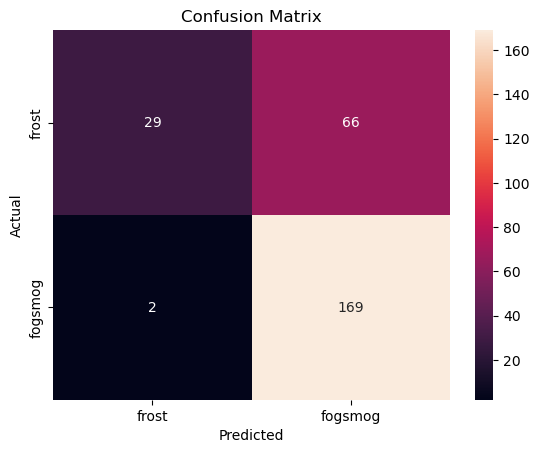

F1 Score :  0.8325123152709359
Accuracy Score :  0.7443609022556391


In [12]:
# Compute Test Accuracy
y_pred = svm.predict(X_test)
accuracy = np.mean(y_pred == y_test) * 100

print( "Test Accuracy : ", accuracy)
print( "Confusion Matrix : \n", confusion_matrix(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
# 1 is fogsmog, 0 is frost
plt.xticks([0.5, 1.5], ['frost', 'fogsmog'])
plt.yticks([0.5, 1.5], ['frost', 'fogsmog'])
plt.show()
print( "F1 Score : ", f1_score(y_test, y_pred))
print( "Accuracy Score : ", accuracy_score(y_test, y_pred))

In [15]:
print("bias : ", svm.b)
print("weights : ", svm.w)

bias :  0.167069692761478
weights :  [-0.00119214 -0.00755796 -0.00887844 ... -0.00717364 -0.00319608
  0.00196523]


1.c Reshape the support vectors corresponding to the top-5 coefficients to get images of 100 × 100 × 3 and plot these (as images). Similarly, reshape and plot the weight vector w

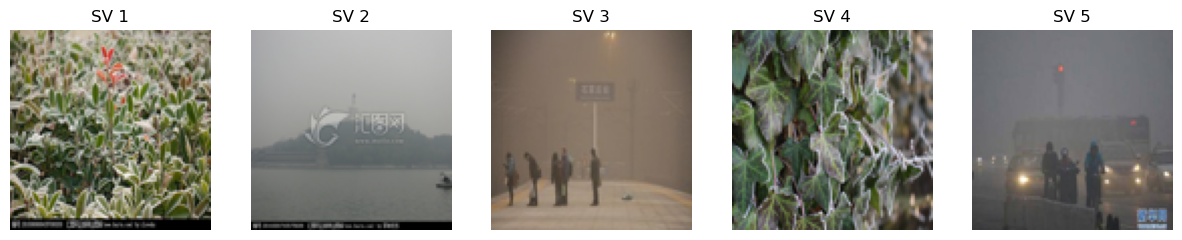

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


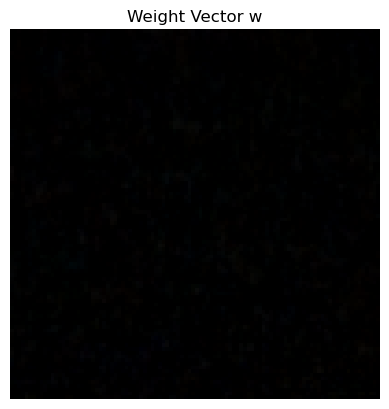

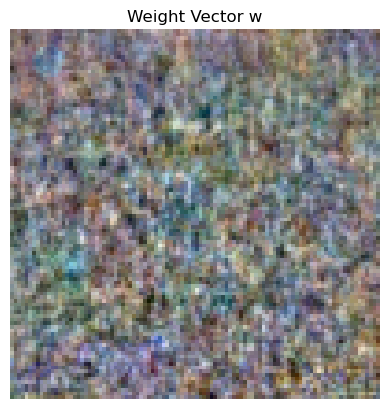

In [17]:
# Reshape Top-5 Support Vectors for Visualization
top_5_sv = svm.support_vectors[:5].reshape(-1, 100, 100, 3)

# Plot Top-5 Support Vectors
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(top_5_sv[i])
    ax.set_title(f"SV {i+1}")
    ax.axis("off")
plt.show()

# Reshape Weight Vector (w) for Visualization
if svm.w is not None:
    w_image = svm.w.reshape(100, 100, 3)
    # Plot Weight Vector (w)
    plt.imshow(w_image,cmap='gray')
    plt.title("Weight Vector w")
    plt.axis("off")
    plt.show()
    # make the colour contrast appear more clearly
    w_image = (w_image - np.min(w_image)) / (np.max(w_image) - np.min(w_image))
    plt.imshow(w_image, cmap="gray")
    plt.title("Weight Vector w")
    plt.axis("off")
    plt.show()

# 2 (5 points) 
Again use the CVXOPT package to solve the dual SVM problem using a Gaussian kernel. Think about how the P matrix will be represented. Use C = 1.0 and γ = 0.001 (i.e. γ in K(x, z) = exp−γ∗∥x−z∥2 ) for this part.

In [17]:
X_train, y_train = combined_train["feature_vector"], combined_train["label"]
X_test, y_test = combined_test["feature_vector"], combined_test["label"]

# Import SVM implementation

X_train = np.array(X_train.tolist())
X_test = np.array(X_test.tolist())
y_train = np.array(y_train)
y_test = np.array(y_test)



svm_gaussian = SupportVectorMachine()

start_time = time.time()
svm_gaussian.fit(X_train, y_train, kernel="gaussian", C=1.0, gamma=0.001)
cvxopt_rbf_time = time.time() - start_time
print("Training Time : ", time.time() - start_time)


Training Time :  1.4458250999450684


2.(a) How many support vectors do you get in this case as compared to the linear case above? How many support vectors obtained here match with the linear case above?


In [18]:
# Count Support Vectors
num_sv_gaussian = len(svm_gaussian.support_vectors)
num_sv_linear = len(svm.support_vectors)  # From previous linear kernel training
matching_sv = np.sum(np.isin(svm_gaussian.support_vectors, svm.support_vectors).all(axis=1))

# Predict Test Labels & Compute Accuracy
y_pred_gaussian = svm_gaussian.predict(X_test)


# Print Results
print(f"Number of Support Vectors (Gaussian Kernel): {num_sv_gaussian}")
print(f"Number of Support Vectors (Linear Kernel): {num_sv_linear}")
print(f"Matching Support Vectors: {matching_sv}")


Number of Support Vectors (Gaussian Kernel): 454
Number of Support Vectors (Linear Kernel): 280
Matching Support Vectors: 454


2.(b) Note that you may not be able to explicitly store the weight vector (w) or the intercept term (b) in this case. Use your learned model to classify the test examples and report the test accuracy.


Test Accuracy (Gaussian Kernel): 93.98%
Confusion Matrix (Gaussian Kernel): 
[[ 87   8]
 [  8 163]]


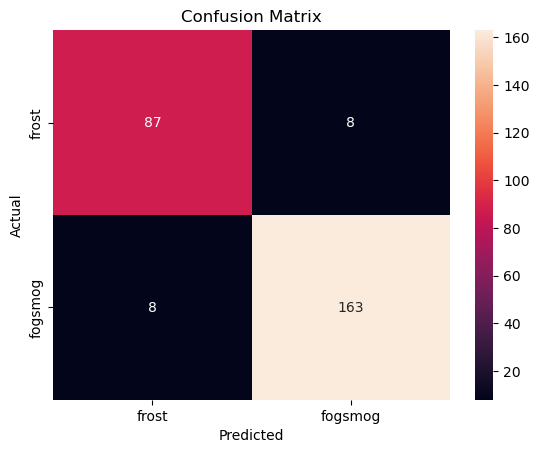

F1 Score (Gaussian Kernel): 0.95
Accuracy Score (Gaussian Kernel): 0.94


In [31]:
y_pred_gaussian = svm_gaussian.predict(X_test)
accuracy_gaussian = np.mean(y_pred_gaussian == y_test) * 100
print(f"Test Accuracy (Gaussian Kernel): {accuracy_gaussian:.2f}%")
print(f"Confusion Matrix (Gaussian Kernel): \n{confusion_matrix(y_test, y_pred_gaussian)}")
sns.heatmap(confusion_matrix(y_test, y_pred_gaussian), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
# 1 is fogsmog, 0 is frost
plt.xticks([0.5, 1.5], ['frost', 'fogsmog'])
plt.yticks([0.5, 1.5], ['frost', 'fogsmog'])
plt.show()
print(f"F1 Score (Gaussian Kernel): {f1_score(y_test, y_pred_gaussian):.2f}")
print(f"Accuracy Score (Gaussian Kernel): {accuracy_score(y_test, y_pred_gaussian):.2f}")

2.(c) Reshape the support vectors corresponding to the top- 5 coefficients to get images of 100 × 100 × 3 and plot these.


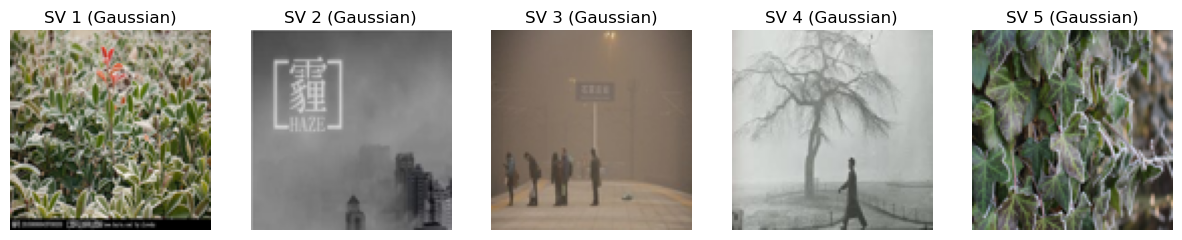

In [23]:
# Reshape & Plot Top-5 Support Vectors
top_5_sv_gaussian = svm_gaussian.support_vectors[:5].reshape(-1, 100, 100, 3)
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(top_5_sv_gaussian[i])
    ax.set_title(f"SV {i+1} (Gaussian)")
    ax.axis("off")
plt.show()

2.(d) Compare the test accuracy obtained here with part (a).

In [24]:

print(f"Test Accuracy (Gaussian Kernel): {accuracy_gaussian:.2f}%")
print(f"Test Accuracy (Linear Kernel from part 1): {accuracy:.2f}%")

Test Accuracy (Gaussian Kernel): 93.98%
Test Accuracy (Linear Kernel from part 1): 74.44%


# 3 (5 points) 
Repeat parts -(a) & (b) with the scikit-learn SVM function, which is based on the LIBSVM package.

In [32]:

# Track Training Time
start_time = time.time()

# Train Sklearn Linear SVM
svm_sklearn_linear = SVC(kernel="linear", C=1.0)
svm_sklearn_linear.fit(X_train, y_train)

# Training Time for Linear SVM
linear_time = time.time() - start_time
start_time = time.time()

# Train Sklearn Gaussian (RBF) SVM
svm_sklearn_rbf = SVC(kernel="rbf", C=1.0, gamma=0.001)
svm_sklearn_rbf.fit(X_train, y_train)

# Training Time for RBF SVM
rbf_time = time.time() - start_time

3.(a) Compare the nSV (Number of Support Vectors) obtained here with the first part for the linear kernel and the second part for the Gaussian kernel. How many of the support vectors obtained here match with the support vectors obtained in both these cases?


In [33]:
# Get Number of Support Vectors
nSV_sklearn_linear = len(svm_sklearn_linear.support_vectors_)
nSV_sklearn_rbf = len(svm_sklearn_rbf.support_vectors_)

# Get Matches with CVXOPT
matching_sv_linear = np.sum(np.isin(svm_sklearn_linear.support_vectors_, svm.support_vectors).all(axis=1))
matching_sv_rbf = np.sum(np.isin(svm_sklearn_rbf.support_vectors_, svm_gaussian.support_vectors).all(axis=1))

print(f"Number of Support Vectors (Sklearn Linear): {nSV_sklearn_linear}")
print(f"Number of Support Vectors (Sklearn RBF): {nSV_sklearn_rbf}")
print(f"Matching SVs (Linear vs CVXOPT): {matching_sv_linear}")
print(f"Matching SVs (RBF vs CVXOPT): {matching_sv_rbf}")

Number of Support Vectors (Sklearn Linear): 496
Number of Support Vectors (Sklearn RBF): 429
Matching SVs (Linear vs CVXOPT): 496
Matching SVs (RBF vs CVXOPT): 429


3.(b) Compare weight (w), bias (b) obtained here with the first part for linear kernel.


In [27]:
# Extract weight vector and bias from Sklearn Linear SVM
w_sklearn = svm_sklearn_linear.coef_.flatten()
b_sklearn = svm_sklearn_linear.intercept_[0]

# Compare with CVXOPT-based SVM
print(f"Weight Vector Difference (||w_sklearn - w_cvxopt||): {np.linalg.norm(w_sklearn - svm.w)}")
print(f"Bias Difference (|b_sklearn - b_cvxopt|): {abs(b_sklearn - svm.b)}")

Weight Vector Difference (||w_sklearn - w_cvxopt||): 0.0008334053116558282
Bias Difference (|b_sklearn - b_cvxopt|): 0.00978891229901524


3.(c) Report the test accuracy for both linear and Gaussian kernel.


In [28]:
# Predict Test Labels
y_pred_sklearn_linear = svm_sklearn_linear.predict(X_test)
y_pred_sklearn_rbf = svm_sklearn_rbf.predict(X_test)

# Compute Accuracy
accuracy_sklearn_linear = np.mean(y_pred_sklearn_linear == y_test) * 100
accuracy_sklearn_rbf = np.mean(y_pred_sklearn_rbf == y_test) * 100


print(f"Test Accuracy (CVXOPT Linear SVM): {accuracy:.2f}%")
print(f"Test Accuracy (CVXOPT RBF SVM): {accuracy_gaussian:.2f}%")
print(f"Test Accuracy (Sklearn Linear SVM): {accuracy_sklearn_linear:.2f}%")
print(f"Test Accuracy (Sklearn RBF SVM): {accuracy_sklearn_rbf:.2f}%")

Test Accuracy (CVXOPT Linear SVM): 74.44%
Test Accuracy (CVXOPT RBF SVM): 93.98%
Test Accuracy (Sklearn Linear SVM): 74.44%
Test Accuracy (Sklearn RBF SVM): 93.98%


3.(d) Compare the computational cost (training time) of the CVXOPT with the sklearn implementation in both the linear and Gaussian case.

In [29]:
print(f"Training Time (CVXOPT Linear SVM): {cvxopt_linear_time:.2f} sec")
print(f"Training Time (Sklearn Linear SVM): {linear_time:.2f} sec")
print(f"Training Time (CVXOPT RBF SVM): {cvxopt_rbf_time:.2f} sec")
print(f"Training Time (Sklearn RBF SVM): {rbf_time:.2f} sec")

Training Time (CVXOPT Linear SVM): 1.34 sec
Training Time (Sklearn Linear SVM): 8.31 sec
Training Time (CVXOPT RBF SVM): 1.56 sec
Training Time (Sklearn RBF SVM): 6.49 sec


# 4 (4 points) 
SVM objective can also be optimized using the SGD algorithm. Report the training time and accuracy on the given dataset. How does the SGD solver fair against LIBLINEAR?

In [41]:
# Track Training Time
start_time = time.time()

# Train SGD-based SVM
sgd_svm = SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3)
sgd_svm.fit(X_train, y_train)

# Training Time
sgd_time = time.time() - start_time

# Predict Test Labels
y_pred_sgd = sgd_svm.predict(X_test)

# Compute Accuracy
accuracy_sgd = np.mean(y_pred_sgd == y_test) * 100

# Track Training Time
start_time = time.time()

# Print Results
print(f"Training Time (SGD SVM): {sgd_time:.2f} sec")
print(f"Test Accuracy (SGD SVM): {accuracy_sgd:.2f}%")

# Compare with Sklearn LIBLINEAR SVM
print(f"Training Time (Sklearn Linear SVM): {linear_time:.2f} sec")
print(f"Test Accuracy (Sklearn Linear SVM): {accuracy_sklearn_linear:.2f}%")


# Compare with CVXOPT-based SVM
print(f"Training Time (CVXOPT Linear SVM): {cvxopt_linear_time:.2f} sec")
print(f"Test Accuracy (CVXOPT Linear SVM): {accuracy:.2f}%")



NameError: name 'X_train' is not defined

# B (17 points) Multi-Class Image Classification:
In this section, we will use the full subset of data provided in Question 2 to tackle a multi-class classification problem using Support Vector Machines (SVMs). For this task, we will utilize the Gaussian kernel to capture complex decision boundaries and improve classification performance.

In [19]:
from itertools import combinations

unique_classes = train_img.keys()
class_pairs = list(combinations(unique_classes, 2))  # Generate all (k choose 2) pairs

# Dictionary to store trained SVMs
ovo_svm_models = {}
time_taken = []



# Train SVM for each class pair
for (class_1, class_2) in class_pairs:
    # Select training data for this pair
    print(f"Training SVM for classes {class_1} vs {class_2}...")
    class_1_train = train_img[class_1]
    class_2_train = train_img[class_2]

    class_1_train['label'] = 1
    class_2_train['label'] = 0

    combined_train = pd.concat([class_1_train, class_2_train], ignore_index=True)

    combined_train = combined_train.sample(frac=1).reset_index(drop=True)


    X_train, y_train = combined_train["feature_vector"], combined_train["label"]
 
    X_train = np.array(X_train.tolist())

    y_train = np.array(y_train)
    # Train SVM with Gaussian Kernel
    start_time = time.time()
    svm = SupportVectorMachine()

    svm.fit(X_train, y_train, kernel="gaussian", C=1.0, gamma=0.001)
    cvxopt_rbf_time = time.time() - start_time

    
    print("Training time: %s seconds" % cvxopt_rbf_time)
    time_taken.append(cvxopt_rbf_time)

    y_pred = svm.predict(X_train)
    accuracy = np.mean(y_pred == y_train) * 100
    print( "Test Accuracy : ", accuracy)
    # Store the trained model
    ovo_svm_models[(class_1, class_2)] = svm
    del X_train, y_train
    del class_1_train, class_2_train, combined_train

print(f"Trained {len(ovo_svm_models)} one-vs-one SVM classifiers.")

Training SVM for classes lightning vs sandstorm...
Training time: 1.05364990234375 seconds
Test Accuracy :  99.06323185011709
Training SVM for classes lightning vs glaze...
Training time: 0.8612258434295654 seconds
Test Accuracy :  99.01477832512316
Training SVM for classes lightning vs rain...
Training time: 0.6922571659088135 seconds
Test Accuracy :  98.19694868238558
Training SVM for classes lightning vs rime...
Training time: 1.7589926719665527 seconds
Test Accuracy :  99.10496338486574
Training SVM for classes lightning vs frost...
Training time: 0.626929759979248 seconds
Test Accuracy :  98.82525697503671
Training SVM for classes lightning vs fogsmog...
Training time: 1.2736198902130127 seconds
Test Accuracy :  98.67482161060143
Training SVM for classes lightning vs hail...
Training time: 1.1737639904022217 seconds
Test Accuracy :  99.35316946959897
Training SVM for classes lightning vs dew...
Training time: 1.0671908855438232 seconds
Test Accuracy :  99.30151338766007
Training S

# 5. (4 points) 
In class, we described the SVM formulation for a binary classification problem. In order to extend this to the multi-class setting, we train a model on each pair of classes to get kC2 classifiers, k being the number of classes (here, k = 11). During prediction time, we output the class which has the maximum number of votes from all the kC2 classifiers. You can read more about one-vs-one classifier setting at the following link. Using your CVXOPT solver from previous section, implement one-vs-one multi-class SVM. Use a Gaussian Kernel with C = 1.0 and γ = 0.001.

In [20]:
combined_test = pd.DataFrame(columns=[ 'image_id', 'feature_vector', 'label'])

for class_ in test_img.keys():
    print(class_)

    test_img[class_]['label'] = class_
    combined_test = pd.concat([combined_test, test_img[class_]], ignore_index=True)
    

combined_test = combined_test.sample(frac=1).reset_index(drop=True)

X_test, y_test = combined_test["feature_vector"], combined_test["label"]
X_test = np.array(X_test.tolist())
y_test = np.array(y_test.tolist())
unique_classes = ["lightning", "sandstorm", "glaze", "rain", "rime", "frost", "fogsmog", "hail", "dew", "rainbow", "snow"]

# Create a mapping from class names to numbers
class_to_index = {cls: i for i, cls in enumerate(unique_classes)}

# Reverse mapping for predictions
index_to_class = {i: cls for i, cls in enumerate(unique_classes)}

# convert class labels to indices in y_test
print(class_to_index)
print(y_test)
y_test = np.array([class_to_index[y] for y in y_test])
print(X_test.shape)
print(y_test.shape)

lightning
sandstorm
glaze
rain
rime
frost
fogsmog
hail
dew
rainbow
snow
{'lightning': 0, 'sandstorm': 1, 'glaze': 2, 'rain': 3, 'rime': 4, 'frost': 5, 'fogsmog': 6, 'hail': 7, 'dew': 8, 'rainbow': 9, 'snow': 10}
['sandstorm' 'dew' 'rainbow' ... 'rime' 'rime' 'rime']
(1378, 30000)
(1378,)


In [29]:


votes = np.zeros((len(X_test), len(unique_classes)))
confidence_scores = np.zeros((len(X_test), len(unique_classes)))  # Store SVM decision function values

for (class_1, class_2), svm in ovo_svm_models.items():

    Nclass_1 = class_to_index[class_1]
    Nclass_2 = class_to_index[class_2]

    print(f"Predicting for classes {class_1} vs {class_2}...{Nclass_1} vs {Nclass_2}")
   
    X_norm = np.sum(X_test**2, axis=1).reshape(-1, 1)
    Z_norm = np.sum(svm.support_vectors**2, axis=1).reshape(1, -1)
    sq_dist = X_norm + Z_norm - 2 * np.dot(X_test, svm.support_vectors.T)
    K_test = np.exp(-svm.gamma * sq_dist)  
    
    decision_values = np.sum(svm.alpha * svm.support_vector_labels * K_test, axis=1) + svm.b # Decision function
    # Convert to probabilities (use a sigmoid approximation)
    confidence = 1 / (1 + np.exp(-decision_values))

    

    pred = (decision_values > 0).astype(int)  # Binary decision (0 or 1)

    count_1 = 0
    count_2= 0 
    for i, p in enumerate(pred):
        if p == 0:
            count_2 +=1
            votes[i, Nclass_2] += 1
            confidence_scores[i, Nclass_2] += confidence[i]
        else:
            count_1+=1
            votes[i, Nclass_1] += 1
            confidence_scores[i, Nclass_1] += confidence[i]
    print(count_1,count_2)
# Resolve ties: If votes are tied, choose the class with highest confidence


y_pred_ovo = np.argmax(votes + 0.0001 * confidence_scores, axis=1)

# Compute final test accuracy


accuracy_ovo = np.mean(y_pred_ovo == y_test) *100


Predicting for classes lightning vs sandstorm...0 vs 1
454 924
Predicting for classes lightning vs glaze...0 vs 2
186 1192
Predicting for classes lightning vs rain...0 vs 3
226 1152
Predicting for classes lightning vs rime...0 vs 4
240 1138
Predicting for classes lightning vs frost...0 vs 5
198 1180
Predicting for classes lightning vs fogsmog...0 vs 6
507 871
Predicting for classes lightning vs hail...0 vs 7
245 1133
Predicting for classes lightning vs dew...0 vs 8
232 1146
Predicting for classes lightning vs rainbow...0 vs 9
551 827
Predicting for classes lightning vs snow...0 vs 10
259 1119
Predicting for classes sandstorm vs glaze...1 vs 2
348 1030
Predicting for classes sandstorm vs rain...1 vs 3
464 914
Predicting for classes sandstorm vs rime...1 vs 4
419 959
Predicting for classes sandstorm vs frost...1 vs 5
424 954
Predicting for classes sandstorm vs fogsmog...1 vs 6
682 696
Predicting for classes sandstorm vs hail...1 vs 7
458 920
Predicting for classes sandstorm vs dew...1 vs

In [28]:
for x in votes:
    print(x)

[10.  1.  2.  7.  6.  3.  0.  4.  8.  5.  9.]
[10.  4.  3.  5.  7.  2.  9.  1.  0.  8.  6.]
[10.  0.  2.  7.  9.  5.  4.  3.  1.  6.  8.]
[10.  8.  3.  2.  1.  5.  7.  4.  6.  9.  0.]
[ 0.  6.  2.  3.  9.  4. 10.  5.  1.  7.  8.]
[ 8.  8.  3.  2.  1.  5. 10.  4.  6.  8.  0.]
[10.  7.  4.  1.  2.  5.  3.  6.  9.  8.  0.]
[10.  8.  3.  9.  0.  7.  5.  6.  4.  1.  2.]
[ 8.  7.  2.  1.  3.  4.  9.  6.  5. 10.  0.]
[10.  1.  4.  6.  2.  5.  0.  9.  7.  8.  3.]
[ 5.  8.  0.  3.  7.  1.  9.  2.  4. 10.  6.]
[10.  1.  4.  2.  6.  4.  5.  0.  9.  8.  6.]
[ 6. 10.  6.  3.  0.  4.  7.  7.  9.  1.  2.]
[10.  9.  5.  1.  2.  4.  7.  3.  6.  8.  0.]
[10.  6.  3.  5.  0.  4.  2.  8.  7.  9.  1.]
[10.  0.  5.  6.  9.  3.  1.  4.  2.  8.  7.]
[ 7. 10.  3.  4.  0.  5.  8.  9.  6.  2.  1.]
[10.  3.  4.  9.  1.  8.  0.  7.  5.  6.  2.]
[10.  5.  2.  8.  0.  9.  3.  7.  6.  4.  1.]
[10.  7.  1.  4.  6.  0.  9.  2.  3.  8.  5.]
[ 2.  9.  5.  3.  7.  1. 10.  4.  0.  8.  6.]
[10.  1.  3.  7.  2.  6.  0.  8.  

Test Accuracy (One-vs-One SVM with Gaussian Kernel, Tie-Breaking): 65.75%
Confusion Matrix (One-vs-One SVM with Gaussian Kernel, Tie-Breaking): 
[[ 67   0   0   0   2   0   3   0   3   0   1]
 [  3 106   4   2   4   1  16   0   1   2   0]
 [  2   1  54  12  15  13   7   5   5   0  14]
 [  2   1   7  60   2   4   6   6   6   0  12]
 [  1   1  10   5 170   3  17   3   0   3  19]
 [  2   8  12   4   8  37   0   7   7   0  10]
 [  2   6   2   2   3   0 152   0   0   0   4]
 [  3   0   4  12   4   8   3  74   4   0   7]
 [  5   3   5   0   4   5   3  10 100   1   4]
 [  2   7   0   3  14   2   4   1   0  13   1]
 [  0   1   7  10  19   4   4   7   0   0  73]]


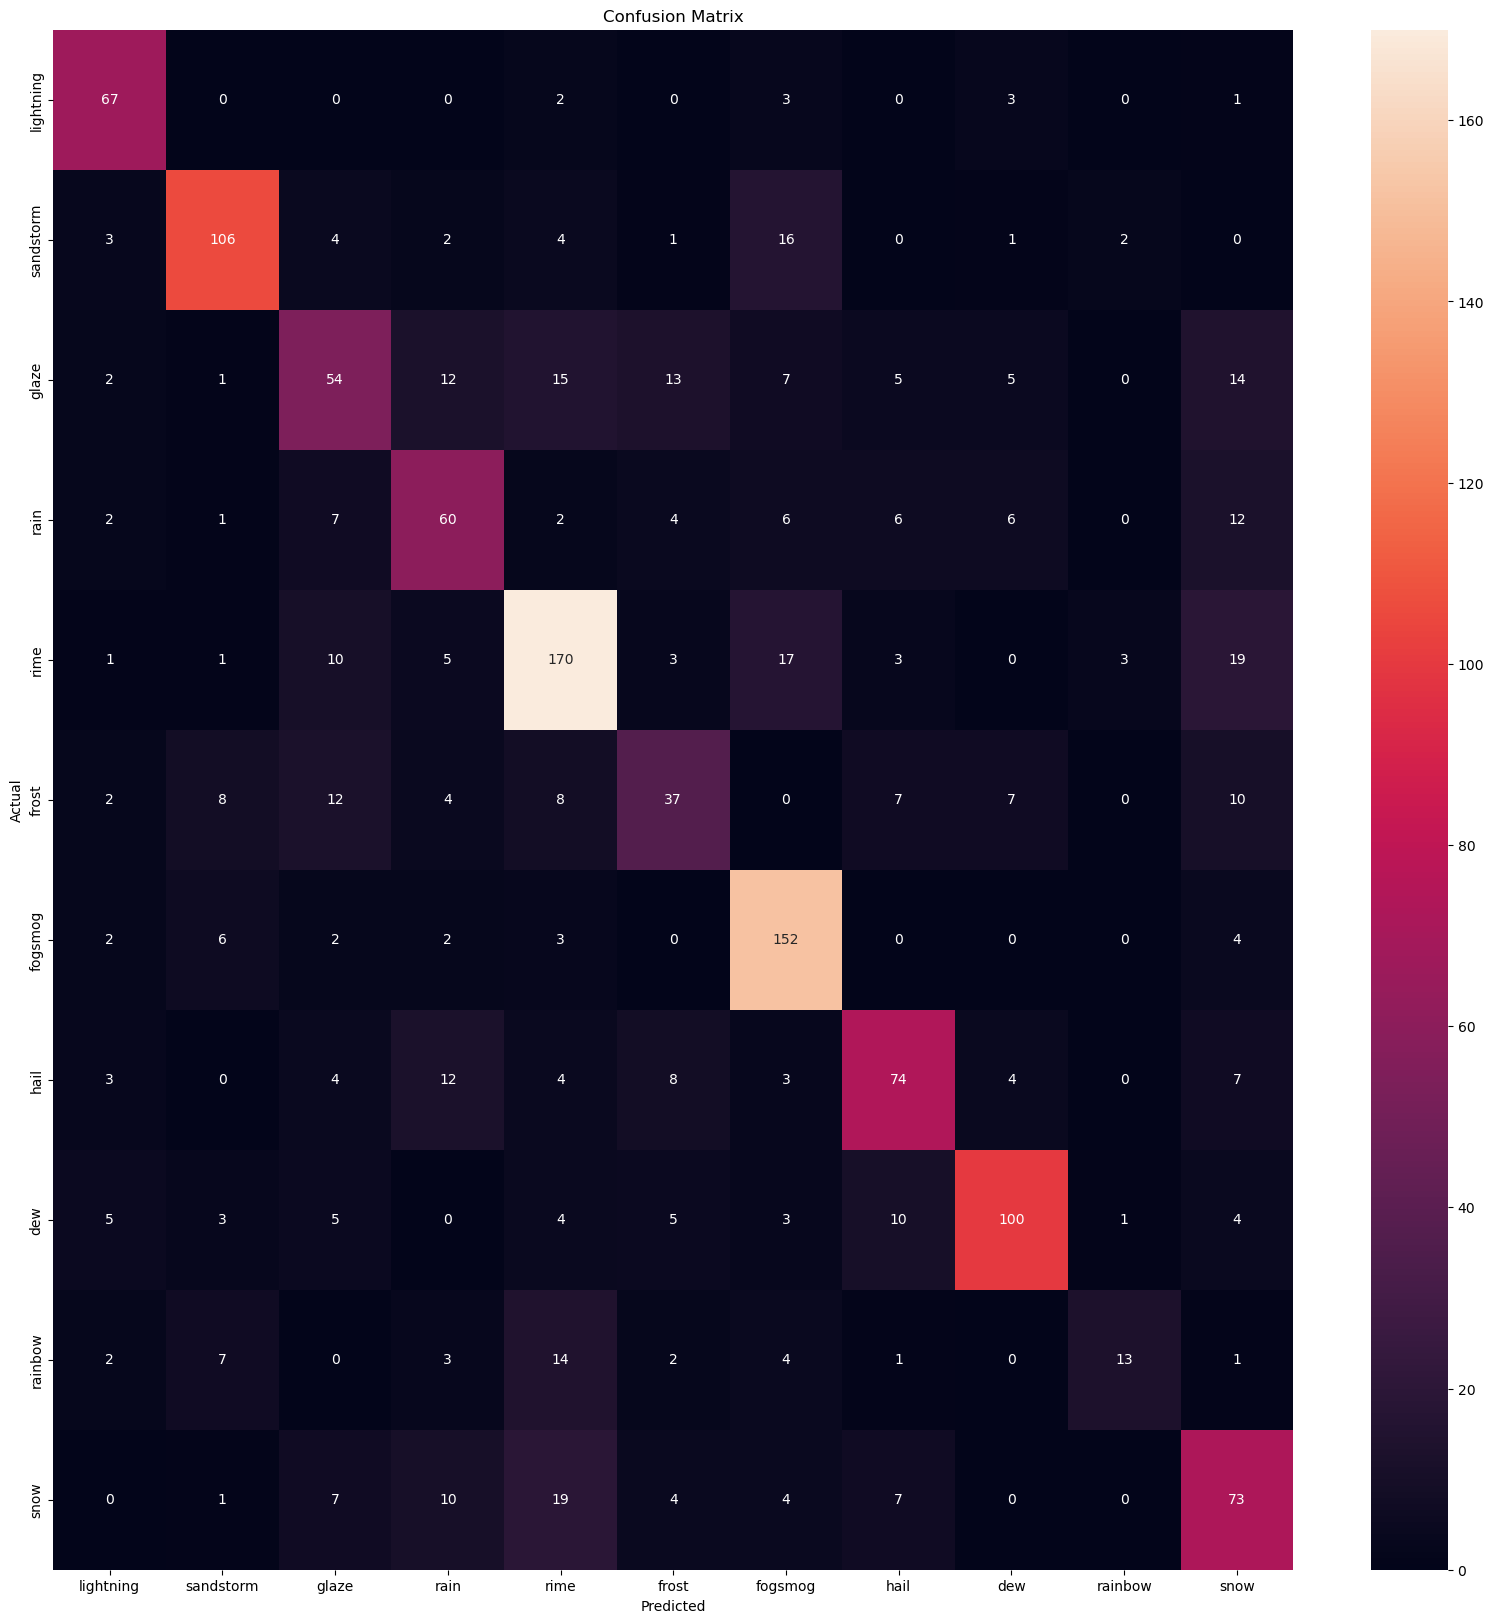

In [41]:
print(f"Test Accuracy (One-vs-One SVM with Gaussian Kernel, Tie-Breaking): {accuracy_ovo:.2f}%")

print(f"Confusion Matrix (One-vs-One SVM with Gaussian Kernel, Tie-Breaking): \n{confusion_matrix(y_test, y_pred_ovo)}")
sns.heatmap(confusion_matrix(y_test, y_pred_ovo), annot=True, fmt='d')
plt.gcf().set_size_inches(20, 20)
#increase font size insize the heatmap

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')


ticks = []
ticks_label = []

for ind in index_to_class.keys():
    ticks.append(ind + 0.5)
    ticks_label.append(index_to_class[ind])
plt.xticks(ticks,ticks_label)
plt.yticks(ticks,ticks_label)
plt.show()



Number of Misclassified Images: 472


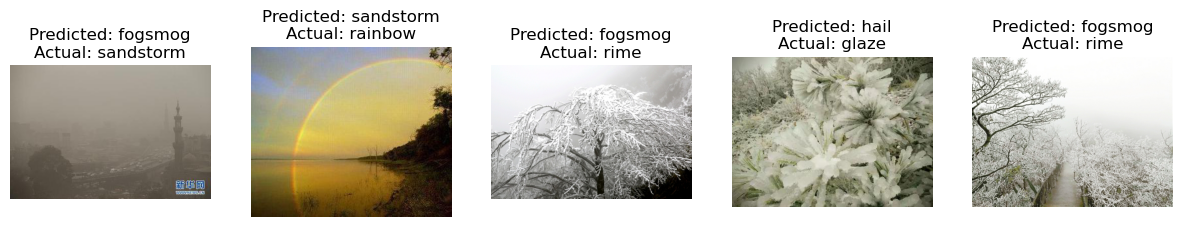

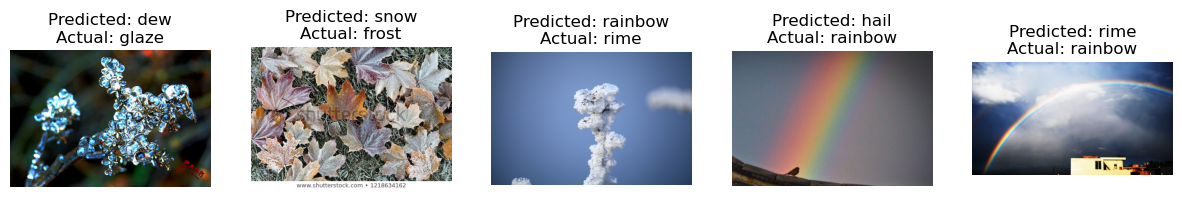

In [51]:
#show image number of images that are most misclassified

misclassified = np.where(y_pred_ovo != y_test)[0]
num_misclassified = len(misclassified)
print(f"Number of Misclassified Images: {num_misclassified}")

#take X_test and y_test and get the image_id of the misclassified images along with label
misclassified_image_ids = combined_test.iloc[misclassified]["image_id"]
misclassified_labels = combined_test.iloc[misclassified]["label"]

# Display the first 5 misclassified images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    img_path = os.path.join('../data/Q2/test', misclassified_labels.iloc[i], f"{misclassified_image_ids.iloc[i]}.jpg")
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"Predicted: {index_to_class[y_pred_ovo[misclassified[i]]]}\nActual: {misclassified_labels.iloc[i]}")
    ax.axis("off")
plt.show()
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    img_path = os.path.join('../data/Q2/test', misclassified_labels.iloc[i+5], f"{misclassified_image_ids.iloc[i+5]}.jpg")
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"Predicted: {index_to_class[y_pred_ovo[misclassified[i+5]]]}\nActual: {misclassified_labels.iloc[i+5]}")
    ax.axis("off")
plt.show()

5.(a) Classify the test examples and report test set accuracy. In case of ties, choose the label
with the highest score.

# 6 (3 points) 
Now train a multi-class SVM on this dataset using the scikit-learn SVM function, which is based on the LIBSVM package. Repeat part (a) using a Gaussian kernel with γ = 0.001. Use C = 1.0 as earlier.

In [34]:
combined_train = pd.DataFrame(columns=[ 'image_id', 'feature_vector', 'label'])

for class_ in train_img.keys():
    print(class_)
    train_img[class_]['label'] = class_
    combined_train = pd.concat([combined_train, train_img[class_]], ignore_index=True)

combined_train = combined_train.sample(frac=1).reset_index(drop=True)

X_train, y_train = combined_train["feature_vector"], combined_train["label"]
X_train = np.array(X_train.tolist())
y_train = np.array(y_train)


print(X_train.shape)
print(y_train.shape)
unique_classes = ["lightning", "sandstorm", "glaze", "rain", "rime", "frost", "fogsmog", "hail", "dew", "rainbow", "snow"]
combined_train

y_train = np.array([class_to_index[y] for y in y_train])

lightning
sandstorm
glaze
rain
rime
frost
fogsmog
hail
dew
rainbow
snow
(5484, 30000)
(5484,)


In [35]:
import time
from sklearn.svm import SVC

# Track training time
start_time = time.time()

# Train LIBSVM Multi-Class SVM with Gaussian Kernel
svm_sklearn = SVC(kernel="rbf", C=1.0, gamma=0.001, decision_function_shape="ovo")  # One-vs-One by default
svm_sklearn.fit(X_train, y_train)

# Compute training time
training_time_sklearn = time.time() - start_time

print(f"Training Time (Sklearn Multi-Class SVM): {training_time_sklearn:.2f} sec")

Training Time (Sklearn Multi-Class SVM): 453.67 sec


6.(a) Classify the test examples and report test set accuracy.

In [36]:
# Predict Test Labels
y_pred_sklearn = svm_sklearn.predict(X_test)

# Compute Test Accuracy
accuracy_sklearn = np.mean(y_pred_sklearn == y_test) * 100

print(f"Test Accuracy (Sklearn Multi-Class SVM): {accuracy_sklearn:.2f}%")


Test Accuracy (Sklearn Multi-Class SVM): 66.04%


Confusion Matrix (Sklearn Multi-Class SVM): 
[[ 65   0   0   0   3   0   4   0   3   0   1]
 [  3 106   3   2   4   1  17   0   1   2   0]
 [  2   1  59  11  16  10   7   5   4   0  13]
 [  2   1   8  58   2   4   6   7   6   0  12]
 [  1   1  10   5 178   3  17   3   0   0  14]
 [  2   7  13   4  10  36   0   7   6   0  10]
 [  2   5   3   1   5   0 153   0   0   0   2]
 [  3   0   5  12   5   7   2  75   4   0   6]
 [  5   4   5   0   4   6   2  10  99   1   4]
 [  2   7   0   3  14   2   5   1   0  12   1]
 [  0   1  10  10  23   2   3   7   0   0  69]]


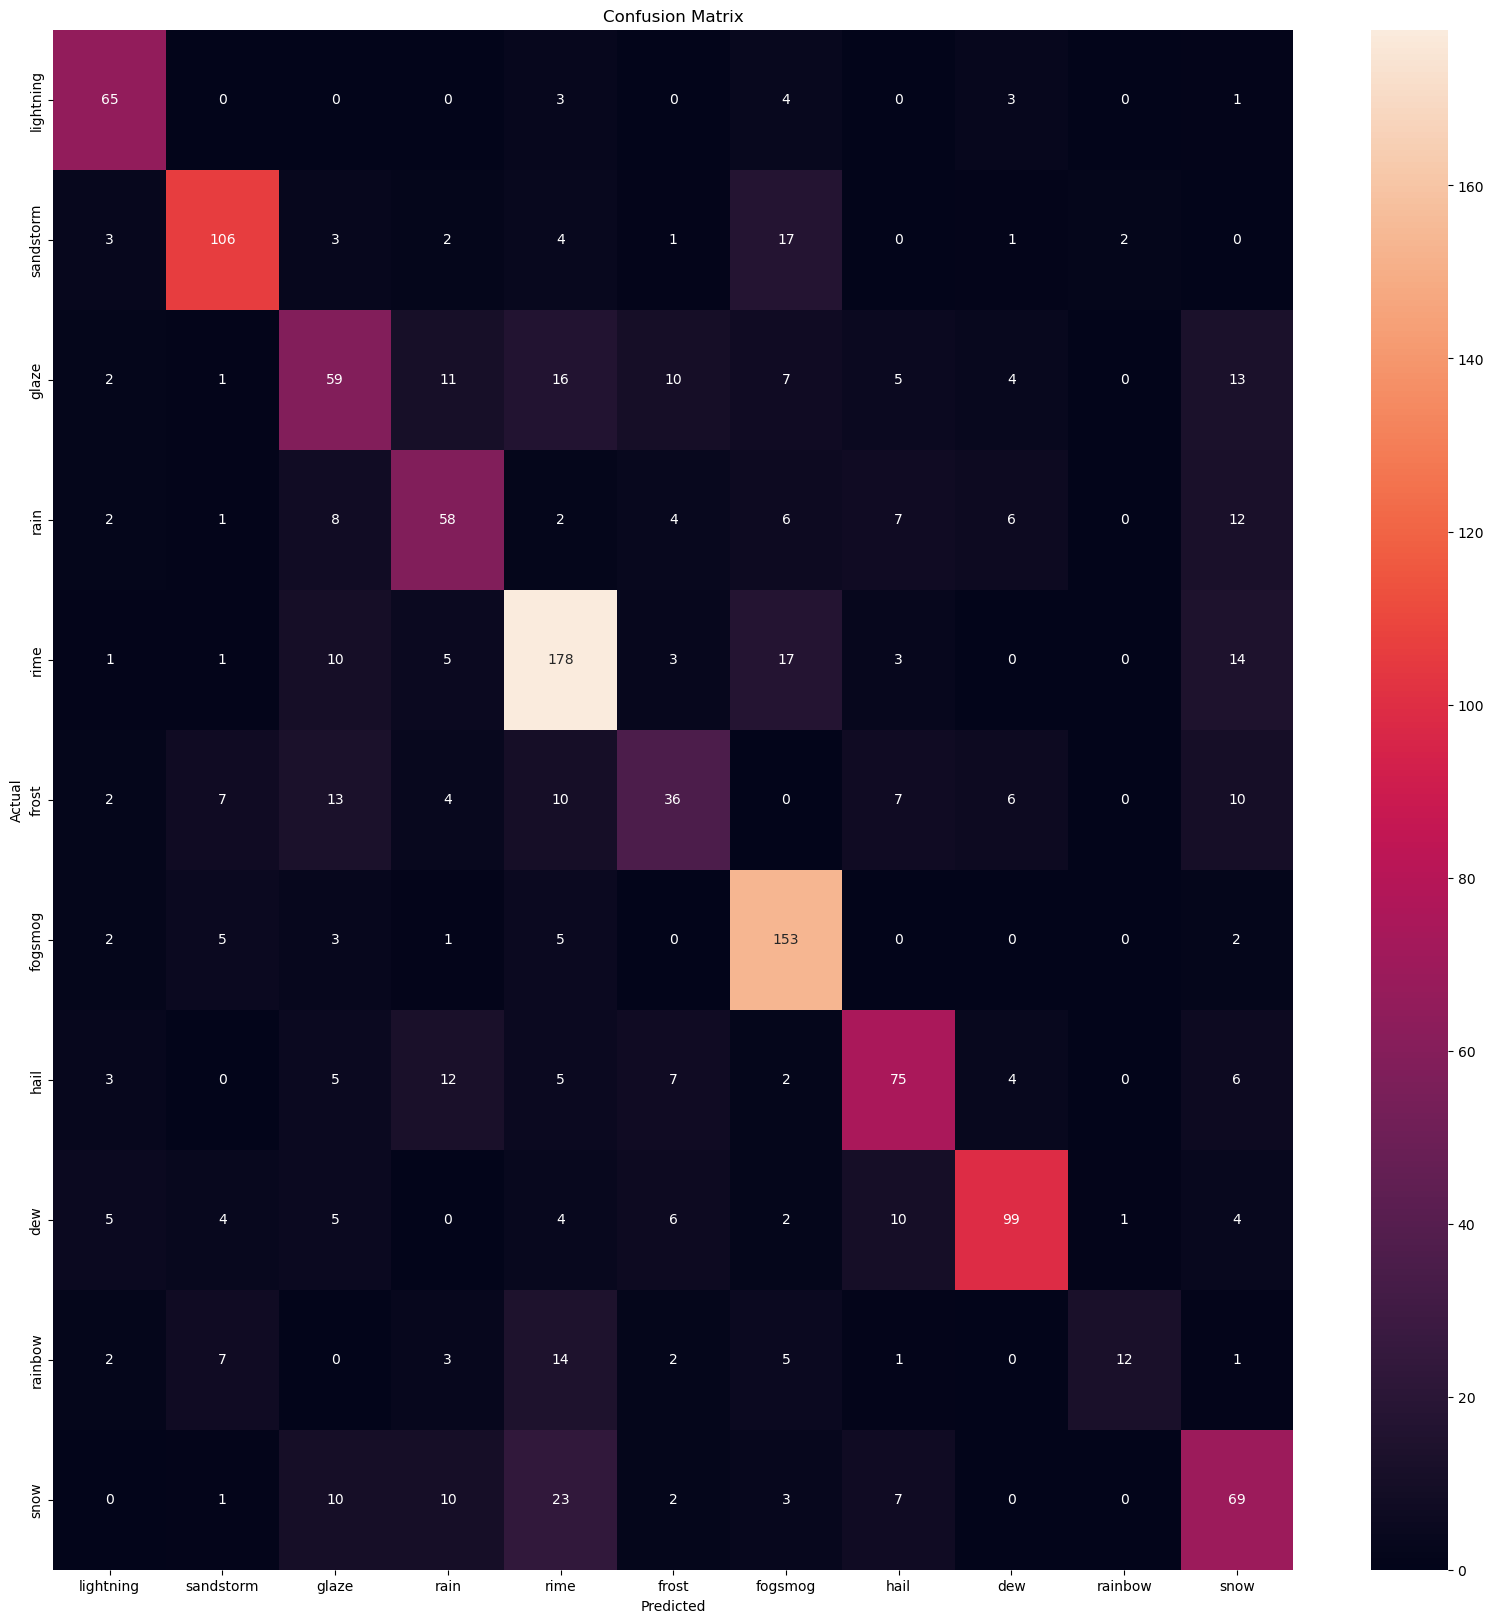

In [38]:
print(f"Confusion Matrix (Sklearn Multi-Class SVM): \n{confusion_matrix(y_test, y_pred_sklearn)}")
sns.heatmap(confusion_matrix(y_test, y_pred_sklearn), annot=True, fmt='d' )
# increase size of heatmap to 20x20
plt.gcf().set_size_inches(20, 20)
#increase font size insize the heatmap

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')


ticks = []
ticks_label = []

for ind in index_to_class.keys():
    ticks.append(ind + 0.5)
    ticks_label.append(index_to_class[ind])
plt.xticks(ticks,ticks_label)
plt.yticks(ticks,ticks_label)
plt.show()


6.(b) How do the test set accuracy and the training time obtained here compare with part (a) above?

In [52]:
training_time_ovo = np.sum(time_taken)

print(f"Test Accuracy (CVXOPT One-vs-One SVM): {accuracy_ovo:.2f}%")
print(f"Training Time (CVXOPT One-vs-One SVM): {training_time_ovo:.2f} sec")

print(f"Test Accuracy (Sklearn Multi-Class SVM): {accuracy_sklearn:.2f}%")
print(f"Training Time (Sklearn Multi-Class SVM): {training_time_sklearn:.2f} sec")

Test Accuracy (CVXOPT One-vs-One SVM): 0.22%
Training Time (CVXOPT One-vs-One SVM): 1376.95 sec
Test Accuracy (Sklearn Multi-Class SVM): 66.04%
Training Time (Sklearn Multi-Class SVM): 463.24 sec


# 7. (4 points) 
Draw the confusion matrix for both of the above parts CVXOPT and LIBSVM. What do you observe? Which classes are miss-classified into which ones most often? Visualize (and report) 10 examples of misclassified objects. Do the results make sense? Comment.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_cvxopt = confusion_matrix(y_test, y_pred_ovo, labels=unique_classes)
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn, labels=unique_classes)

# Plot Confusion Matrix for CVXOPT SVM

disp_cvxopt = ConfusionMatrixDisplay(confusion_matrix=cm_cvxopt, display_labels=unique_classes)
disp_cvxopt.plot(cmap="Blues", xticks_rotation="vertical")
plt.title("Confusion Matrix - CVXOPT One-vs-One SVM")
# increase size of heatmap to 20x20
plt.gcf().set_size_inches(20, 20)

plt.xlabel('Predicted')
plt.ylabel('Actual')

ticks = []
ticks_label = []

for ind in index_to_class.keys():
    ticks.append(ind + 0.5)
    ticks_label.append(index_to_class[ind])
plt.xticks(ticks,ticks_label)
plt.yticks(ticks,ticks_label)
plt.show()

# Plot Confusion Matrix for Sklearn (LIBSVM)
disp_sklearn = ConfusionMatrixDisplay(confusion_matrix=cm_sklearn, display_labels=unique_classes)
disp_sklearn.plot(cmap="Blues", xticks_rotation="vertical")
# increase size of heatmap to 20x20
plt.gcf().set_size_inches(20, 20)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')


ticks = []
ticks_label = []

for ind in index_to_class.keys():
    ticks.append(ind + 0.5)
    ticks_label.append(index_to_class[ind])
plt.xticks(ticks,ticks_label)
plt.yticks(ticks,ticks_label)
plt.show()

# 8. (6 points) 
The validation set is typically used to estimate the optimal value of model hyperparameters, such as C in our SVM with a Gaussian kernel. This is done by randomly selecting a small subset of the training data as the validation set, training the model on the remaining training data, and then evaluating its performance on the validation set. For a more detailed introduction, you can refer to this video. You can check the correctness of your intuition by trying this test.

A more systematic approach to hyper-parameter tuning is K-fold cross-validation, which is commonly used in practice. In this technique, the training data is divided into K equal parts (folds). Each fold is used as a validation set once, while the remaining K-1 folds are used for training. This process is repeated for a range of hyper-parameter values, and the hyperparameters yielding the highest K-fold cross-validation accuracy are selected as the best. You can read more about cross-validation here 1 (see Section 1) for more details.

For this problem, we will perform 5-fold cross-validation to determine the optimal C value for the Gaussian kernel SVM. The test data should remain untouched throughout this process. We will use the scikit-learn SVM function to implement this approach.

8.(a) Fix γ as 0.001 and vary the value of C in the set {10−5, 10−3, 1, 5, 10} and compute the 5 -fold cross validation accuracy and the test accuracy for each value of C.

In [3]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Define values of C to test
C_values = [1e-5, 1e-3, 1, 5, 10]
gamma_value = 0.001  # Fixed γ

# Store cross-validation and test accuracies
cv_accuracies = []
test_accuracies = []

# Perform cross-validation for each C
for C in C_values:
    print(f"Training with C = {C}...")

    # Initialize SVM with Gaussian (RBF) kernel
    svm_model = SVC(kernel="rbf", C=C, gamma=gamma_value)

    # Perform 5-Fold Cross-Validation
    cv_scores = cross_val_score(svm_model, X_train, y_train, cv=5)  # Default is accuracy
    cv_accuracy = np.mean(cv_scores) * 100  # Convert to percentage

    # Train SVM on full training data and evaluate on test set
    svm_model.fit(X_train, y_train)
    test_accuracy = np.mean(svm_model.predict(X_test) == y_test) * 100

    # Store results
    cv_accuracies.append(cv_accuracy)
    test_accuracies.append(test_accuracy)

    print(f"5-Fold CV Accuracy: {cv_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

Training with C = 1e-05...


NameError: name 'X_train' is not defined

8.(b) Now, plot both the 5-fold cross validation accuracy as well as the test set accuracy on a graph as you vary the value of C on x-axis (you may use log scale on x-axis). What do you observe? Which value of C gives the best 5 -fold cross validation accuracy?


In [ ]:
# Plot the results
plt.figure(figsize=(8,6))
plt.plot(C_values, cv_accuracies, marker="o", linestyle="--", label="5-Fold CV Accuracy")
plt.plot(C_values, test_accuracies, marker="s", linestyle="-", label="Test Accuracy")

# Log-scale for better visualization
plt.xscale("log")
plt.xlabel("C Value (Log Scale)")
plt.ylabel("Accuracy (%)")
plt.title("Hyperparameter Tuning: C vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()

8.(c) Train an SVM classifier using the above found hyperparameter C (on the entire train set) and report the accuracy. Does this value of C improve accuracy from the previous modelaccuracy of the test set? Comment on your observations.

In [2]:
# Find best C based on Cross-Validation Accuracy
best_C = C_values[np.argmax(cv_accuracies)]
print(f"Best C from Cross-Validation: {best_C}")

# Train final model using best C
final_svm = SVC(kernel="rbf", C=best_C, gamma=gamma_value)
final_svm.fit(X_train, y_train)

# Compute final test accuracy
final_test_accuracy = np.mean(final_svm.predict(X_test) == y_test) * 100

print(f"Final Model Test Accuracy (with C={best_C}): {final_test_accuracy:.2f}%")

NameError: name 'C_values' is not defined